# Where do older adults lack a car?

**Business question:** How many older households have no car, where are they, and can they afford my rate? What does that mean for my rule that I do not drive clients in my own vehicle?

**Why it matters:** A household with no car needs someone to run errands and to come along on trips by rideshare, taxi, transit or paratransit. That is work I offer. It is also the household most likely to ask for a ride, which I do not offer.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Settings you can change

- **INCOME_LINE** is the household income at which a weekly visit is comfortable. It comes from notebook 05: one 4-hour visit a week at &#36;35 an hour, costing up to 12% of income.
- **MIN_HOUSEHOLDS** is the smallest number of car-free older households that makes an area worth noting. It is my judgment call.

In [7]:
RATE, MIN_HOURS, BUDGET_SHARE = 35, 4, 0.12
INCOME_LINE = RATE * MIN_HOURS * 52 / BUDGET_SHARE
MIN_HOUSEHOLDS = 300
print(f"A weekly visit is comfortable at a household income of about ${INCOME_LINE:,.0f} or more.")

A weekly visit is comfortable at a household income of about $60,667 or more.


## 2. Count older households with no car

- **no_car_households**: households headed by someone 65+ with no vehicle.
- **share_no_car**: those households as a share of all older households in the area.
- **typical_household_income**: median income of all households headed by someone 65+ in the area. It describes the area, not car-free households in particular.

In [8]:
t = table[["area"]].copy()
t["no_car_households"] = table["hh65_no_vehicle"]
t["older_households"] = table["hh65_no_vehicle"] + table["hh65_with_vehicle"]
t["share_no_car"] = t["no_car_households"] / t["older_households"]
t["typical_household_income"] = table["median_income_65plus_hh"]
t["can_likely_pay"] = t["typical_household_income"] >= INCOME_LINE

def fit(row):
    if row["no_car_households"] < MIN_HOUSEHOLDS:
        return "Few without a car"
    return "No car, can likely pay" if row["can_likely_pay"] else "No car, tight budgets"
t["fit"] = t.apply(fit, axis=1)
t = t.sort_values("no_car_households", ascending=False)
t.round(2)

,area,no_car_households,older_households,share_no_car,typical_household_income,can_likely_pay,fit
zip,,,,,,,
94612,"Oakland, downtown",1834,2632,0.70,19241,False,"No car, tight budgets"
94606,"Oakland, San Antonio / Eastlake",1264,3089,0.41,33565,False,"No car, tight budgets"
94607,"Oakland, West Oakland / Chinatown",1209,2591,0.47,24362,False,"No car, tight budgets"
94501,"Alameda, main island",1036,6150,0.17,69740,True,"No car, can likely pay"
94611,"Oakland, Montclair / Piedmont",983,5760,0.17,110769,True,"No car, can likely pay"
94601,"Oakland, Fruitvale",752,3626,0.21,41107,False,"No car, tight budgets"
94702,"Berkeley, west",748,2390,0.31,49167,False,"No car, tight budgets"
94610,"Oakland, Grand Lake",686,3608,0.19,102315,True,"No car, can likely pay"
94608,Emeryville / North Oakland,662,2412,0.27,48580,False,"No car, tight budgets"


## 3. What the numbers say

The link score compares two rankings of the areas: by share of older households with no car, and by typical income. A score near -1 means the lower the income, the more households go without a car.

In [9]:
total, all_hh = t["no_car_households"].sum(), t["older_households"].sum()
print(f"{total:,.0f} older households have no car: {total / all_hh:.0%} of older households, about 1 in {all_hh / total:.0f}.")
link = t["share_no_car"].rank().corr(t["typical_household_income"].rank())
print(f"Link between going without a car and income: {link:.2f}")

tight = t[~t["can_likely_pay"]]
print(f"{tight['no_car_households'].sum() / total:.0%} of car-free older households live in areas where the typical income is below the line.\n")

for label in ["No car, can likely pay", "No car, tight budgets"]:
    rows = t[t["fit"] == label]
    print(f"{label}: {len(rows)} areas, {rows['no_car_households'].sum():,.0f} households")
    for z, row in rows.iterrows():
        print(f"   {z}  {row['area']}: {row['no_car_households']:,.0f} households ({row['share_no_car']:.0%}), "
              f"typical household income ${row['typical_household_income']:,.0f}")
    print()

pay = t[t["can_likely_pay"]]
share = pay["no_car_households"].sum() / pay["older_households"].sum()
print("What this means for my no-driving rule:")
print(f"   In the {len(pay)} areas where a weekly visit fits the typical income, {share:.0%} of older households have no car "
      f"(about 1 in {1 / share:.0f}).")
print(f"   The other {1 - share:.0%} have a car, so the client or a family member may be able to drive.")

13,517 older households have no car: 21% of older households, about 1 in 5.
Link between going without a car and income: -0.82
55% of car-free older households live in areas where the typical income is below the line.

No car, can likely pay: 10 areas, 5,444 households
   94501  Alameda, main island: 1,036 households (17%), typical household income $69,740
   94611  Oakland, Montclair / Piedmont: 983 households (17%), typical household income $110,769
   94610  Oakland, Grand Lake: 686 households (19%), typical household income $102,315
   94602  Oakland, Glenview / Dimond: 601 households (17%), typical household income $88,351
   94605  Oakland, East Oakland hills: 395 households (10%), typical household income $84,621
   94619  Oakland, Laurel / Redwood Heights: 356 households (13%), typical household income $75,556
   94618  Oakland, Rockridge: 353 households (14%), typical household income $120,179
   94703  Berkeley, central / south: 351 households (18%), typical household income 

## 4. Chart: the ten areas with the most car-free older households

Each bar is the number of older households with no car. Dark bars are areas where a weekly visit fits the typical income. The column on the right is that typical income.

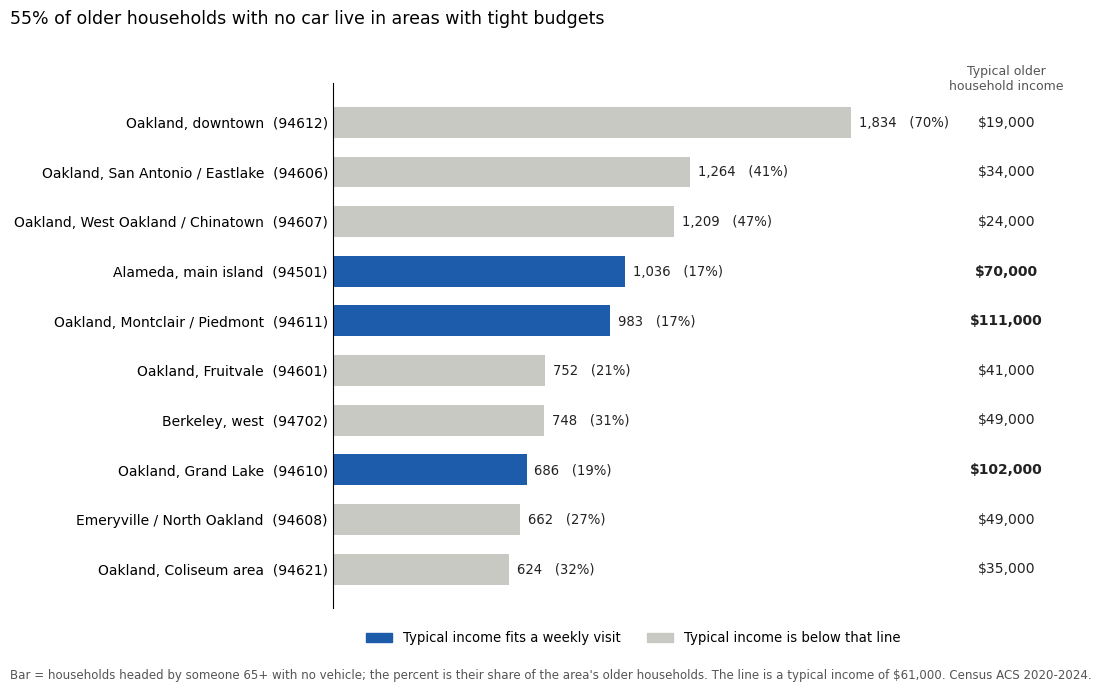

In [10]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

show = t.head(10)
ypos = list(range(len(show)))[::-1]   # first row at the top
labels = [f"{row['area']}  ({z})" for z, row in show.iterrows()]
DARK, GRAY = "#1c5cab", "#c9c9c4"

fig, ax = plt.subplots(figsize=(11, 0.45 * len(show) + 2.4))
ax.barh(ypos, show["no_car_households"], color=[DARK if c else GRAY for c in show["can_likely_pay"]], height=0.62)
longest = show["no_car_households"].max()
col_x = longest * 1.3
for y, (z, row) in zip(ypos, show.iterrows()):
    ax.text(row["no_car_households"] + longest * 0.015, y,
            f"{row['no_car_households']:,.0f}   ({row['share_no_car']:.0%})", va="center", fontsize=9.5, color="#222222")
    ax.text(col_x, y, f"\\${round(row['typical_household_income'], -3):,.0f}", va="center", ha="center", fontsize=10,
            color="#222222", fontweight="bold" if row["can_likely_pay"] else "normal")
ax.text(col_x, len(show) - 0.4, "Typical older\nhousehold income", va="bottom", ha="center", fontsize=9, color="#555555")
ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, longest * 1.45)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
handles = [plt.Rectangle((0, 0), 1, 1, color=DARK), plt.Rectangle((0, 0), 1, 1, color=GRAY)]
ax.legend(handles, ["Typical income fits a weekly visit", "Typical income is below that line"],
          loc="upper center", bbox_to_anchor=(0.4, -0.02), ncol=2, frameon=False, fontsize=9.5)
fig.suptitle(f"{tight['no_car_households'].sum() / total:.0%} of older households with no car live in areas with tight budgets",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.01, f"Bar = households headed by someone 65+ with no vehicle; the percent is their share of the area's older households. "
         f"The line is a typical income of \\${round(INCOME_LINE, -3):,.0f}. Census ACS 2020-2024.",
         fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.03, 1, 0.97))
fig.savefig(f"{OUT}/no_car.png", dpi=150)
t.round(3).to_csv(f"{OUT}/no_car.csv")
plt.show()

## 5. What I decided

- **Keep the no-driving rule?** Yes. In the areas where a weekly visit fits the typical income, about 86% of older households have a car.
- **Where to pitch errands and coming along on trips:** Alameda's main island, Montclair / Piedmont, Grand Lake and Glenview / Dimond, which have the largest groups of car-free older households among the areas that can pay.
- **What to say when a client asks for a ride:** I do not drive clients in my own vehicle. The client or a family member can drive, or I come along by rideshare, taxi, transit or paratransit.

### Limits to remember
- Having a car is not the same as being able to drive it. Some households with a car have an older adult who no longer drives, and the Census cannot see that.
- Income here describes all older households in an area, not car-free households in particular. Car-free households likely earn less than the area's typical household.
- Going without a car can be a choice in walkable areas with good transit, so it does not always mean a need for help.
- ZIP-code estimates are survey-based. Treat close numbers as ties.